In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

# Curve MDP

In [4]:
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_misc")

# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=False)
curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_misc", force_refresh_fixings=False)
# curve_mdp = IRSwapsMDP(source="GSQUANT_RL", force_refresh_fixings=False)

In [5]:
ts = NY_tz.localize(datetime.datetime(2025, 10, 9, 17, 00))
# ts = "live"

# curve_handle = curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=ts, kwargs={"force_refresh": True})
curve_handle = curve_mdp._get_curve(curve_name="USD-FEDFUNDS", timestamp=ts, kwargs={"force_refresh": True})

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 25.79it/s]


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.0006148533629149501, `time`: 0.0869s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 4208.204692667818, `time`: 0.0842s


# O/N fwd curve

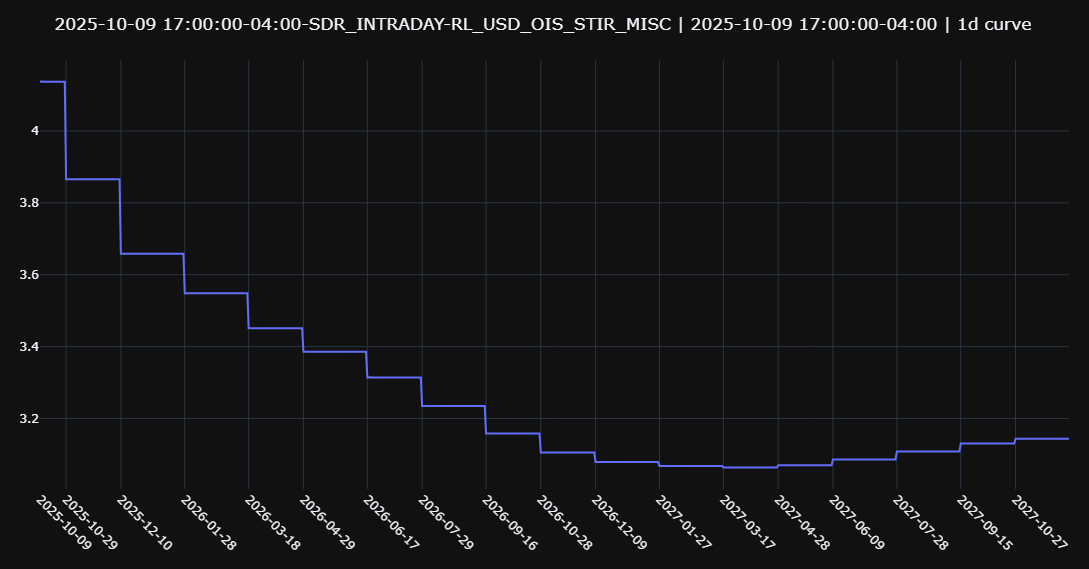

In [6]:
x_data_num, y_data_rate = curve_handle.handle()._plot_rates("1d", left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())
curve_nodes = curve_handle.handle().nodes._nodes.keys()

# fig, ax = plt.subplots()
# ax.plot(x_business_days, y_business_rates)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.xticks(rotation=45, ha="right")  # Rotate ticks for better readability
# ax.grid(True, linestyle="--", alpha=0.6)

# ticks = [t.tz_localize(None) if getattr(t, "tzinfo", None) else t for t in curve_nodes]
# ax.set_xticks(mdates.date2num(ticks))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.title(f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | 1d")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


fig = go.Figure()
fig.add_trace(go.Scatter(x=x_business_days, y=y_business_rates, mode="lines", name="1D"))

tick_vals = [pd.Timestamp(t).tz_localize(None) for t in curve_nodes]
tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]

fig.update_layout(
    title=f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | 1d curve",
    template="plotly_dark",
    margin=dict(l=40, r=20, t=60, b=80),
    xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
    height=550,
    width=1200,
    yaxis=dict(showgrid=True),
)
fig.update_xaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikemode="across",
    showgrid=True,
)
fig.update_yaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikethickness=0.5,
    showgrid=True,
)

fig.show()

# Spot Term Curve

In [28]:
irssfm = IRSwapStructureFunctionMap(curve=curve_handle)

spot_queries = [
    IRSwapQuery(curve="USD-SOFR-1D", tenor="1D", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="1W", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="1M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="2M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="3M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="4M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="5M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="6M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="7M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="8M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="9M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="10M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="11M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="1Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="15M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    IRSwapQuery(curve="USD-SOFR-1D", tenor="18M", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="3Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="4Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="6Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="7Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="8Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="9Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="12Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="15Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="20Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="25Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="40Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
    #     IRSwapQuery(curve="USD-SOFR-1D", tenor="50Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1}),
]

rl_spots = []
for q in spot_queries:
    pkg, _ = irssfm.apply(q.structure, tenor=q.tenor, **q.structure_kwargs)
    rl_spots.append(pkg[0])

x = [curve_handle.calendar_advance(curve_handle.reference_date(), s.__dict__["kwargs"]["termination"]) for s in rl_spots]
y = [s.rate().real for s in rl_spots]

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name="1D"))
tick_vals = [pd.Timestamp(t).tz_localize(None) for t in x]
tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]
fig.update_layout(
    title=f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | spot term curve",
    template="plotly_dark",
    margin=dict(l=40, r=20, t=60, b=80),
    xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
    height=550,
    yaxis=dict(showgrid=True),
)
fig.update_xaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikemode="across",
    showgrid=True,
)
fig.update_yaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikethickness=0.5,
    showgrid=True,
)
fig.show()

# Risk Model

In [100]:
imms = ["Z25", "H26", "M26", "U26", "Z26", "H27", "M27", "U27", "Z27", "H28", "M28", "U28", "Z28"] 
# imms = ["Z25", "H26", "M26", "U26", "Z26", "H27", "M27", "U27", "Z27", "H28", "M28", "U28", "Z28", "H29", "M29", "U29", "Z29"]
sfrs = {}
for imm in imms:
    sfrs[imm] = rl.STIRFuture(
        effective=rl.scheduling.get_imm(code=imm), termination=rl.scheduling.next_imm(rl.scheduling.get_imm(code=imm)), spec="usd_stir", curves=curve_handle.handle()
    )

irssfm = IRSwapStructureFunctionMap(curve=curve_handle)

mt_tenors = ["5Y", "7Y", "10Y", "20Y", "30Y"]
mt_irs = {}
for t in mt_tenors:
    q = IRSwapQuery(curve="USD-SOFR-1D", tenor=t, structure_kwargs={"bpv": 1})
    pkg, _ = irssfm.apply(q.structure, tenor=q.tenor, **q.structure_kwargs)
    mt_irs[t] = pkg[0]


rl_risk_instruments = sfrs | mt_irs
rl_risk_solver = rl.Solver(
    curves=[curve_handle.handle()],
    instruments=rl_risk_instruments.values(),
    instrument_labels=rl_risk_instruments.keys(),
    s=[r.rate().real for r in rl_risk_instruments.values()],
    id=curve_handle.id(),
    func_tol=1e-8,
    conv_tol=1e-10,
)

SUCCESS: `func_tol` reached after 0 iterations (levenberg_marquardt), `f_val`: 0.0, `time`: 0.0038s


In [101]:
def rl_sfr(imm: str, risk=None, contracts=None):
    assert risk or contracts, "must pass in risk or contracts"
    if not contracts:
        contracts = -int(risk / 25)
    return rl.STIRFuture(
        effective=rl.scheduling.get_imm(code=imm),
        termination=rl.scheduling.next_imm(rl.scheduling.get_imm(code=imm)),
        spec="usd_stir",
        curves=curve_handle.handle(),
        contracts=contracts,
    )


def rl_irsq(q: IRSwapQuery):
    pkg, _ = irssfm.apply(q.structure, tenor=q.tenor, **q.structure_kwargs)
    return rl.Portfolio(pkg)

In [102]:
# s1 = IRSwapQuery(curve="USD-SOFR-1D", tenor="3Yx1Y", structure_kwargs={"bpv": 50_000})
# s2 = IRSwapQuery(curve="USD-SOFR-1D", tenor="4Yx1Y", structure_kwargs={"bpv": -100_000})
# s3 = IRSwapQuery(curve="USD-SOFR-1D", tenor="5Yx1Y", structure_kwargs={"bpv": 50_000})
# s4 = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", structure_kwargs={"bpv": 50_000})
# pkg, rws = irssfm.apply(s4.structure, tenor=s4.tenor, **s4.structure_kwargs)
# rl_trade = rl.Portfolio(pkg)

fly = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.FLY, structure_kwargs={"front_tenor": "1Yx1Y", "belly_tenor": "2Yx1Y", "back_tenor": "3Yx1Y", "bpv": -100_000})
pkg, rws = irssfm.apply(fly.structure, tenor=fly.tenor, **fly.structure_kwargs)
rl_trade = rl.Portfolio(pkg)

rl_trade.delta(solver=rl_risk_solver).style.format("{:_.0f}")

In [95]:
# z5z6 = rl.Portfolio([
# 	rl_sfr("Z25", risk=-50_000),
# 	rl_sfr("Z26", risk=50_000)
# ])

# irsq_outright_trade = rl_irsq(IRSwapQuery(curve=curve_handle._rl_curve_id, tenor="IMM_Z25x3Y", structure_kwargs={"bpv": 100_000}))
# irsq_curve_outright.delta(solver=rl_risk_solver).style.format("{:_.0f}")

# irsq_curve_trade = rl_irsq(
#     IRSwapQuery(
#         curve=curve_handle._rl_curve_id, structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "IMM_Z25x2Y", "back_tenor": "IMM_Z25x5Y", "bpv": -100_000}
#     )
# )
# irsq_curve_curve.delta(solver=rl_risk_solver).style.format("{:_.0f}")

irsq_curve_fly = rl_irsq(
    IRSwapQuery(
        curve=curve_handle._rl_curve_id,
        structure=IRSwapStructure.FLY,
        structure_kwargs={"front_tenor": "2Yx3Y", "belly_tenor": "5Yx5Y", "back_tenor": "10Yx20Y", "bpv": -100_000},
    )
)
irsq_curve_fly.delta(solver=rl_risk_solver).style.format("{:_.0f}")

In [101]:
# import requests

# url = "http://localhost:8080/api/auth/login.php"
# payload = {"username": "test", "password": "test"}

# # Use the 'json' parameter to send a proper JSON payload
# res = requests.post(url, json=payload)

# print(res.status_code)
# print(res.json())